# Customer Churn Prediction — EDA & Visualization

**Dataset:** Telco Customer Churn
**Goal:** วิเคราะห์ปัจจัยที่ทำให้ลูกค้า Churn และสร้าง visualization เพื่อทำความเข้าใจข้อมูล


## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

df = pd.read_csv('../data/Telco_Customer_Churn.csv')

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows where TotalCharges is NaN (tenure=0, new customers)
df = df[df['TotalCharges'].notna()].reset_index(drop=True)

# Binary churn column
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Churn rate: {df['Churn_binary'].mean():.1%}")
df.head()


Dataset shape: (7032, 22)
Churn rate: 26.6%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_binary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## 2. Dataset Overview

In [2]:
print("=== Data Types ===")
print(df.dtypes)
print()
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values")
print()
print("=== Numeric Summary ===")
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)


=== Data Types ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
Churn_binary          int64
dtype: object

=== Missing Values ===
No missing values

=== Numeric Summary ===


,tenure,MonthlyCharges,TotalCharges
count,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30
std,24.55,30.09,2266.77
min,1.00,18.25,18.80
25%,9.00,35.59,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.86,3794.74
max,72.00,118.75,8684.80


## 3. Churn Distribution

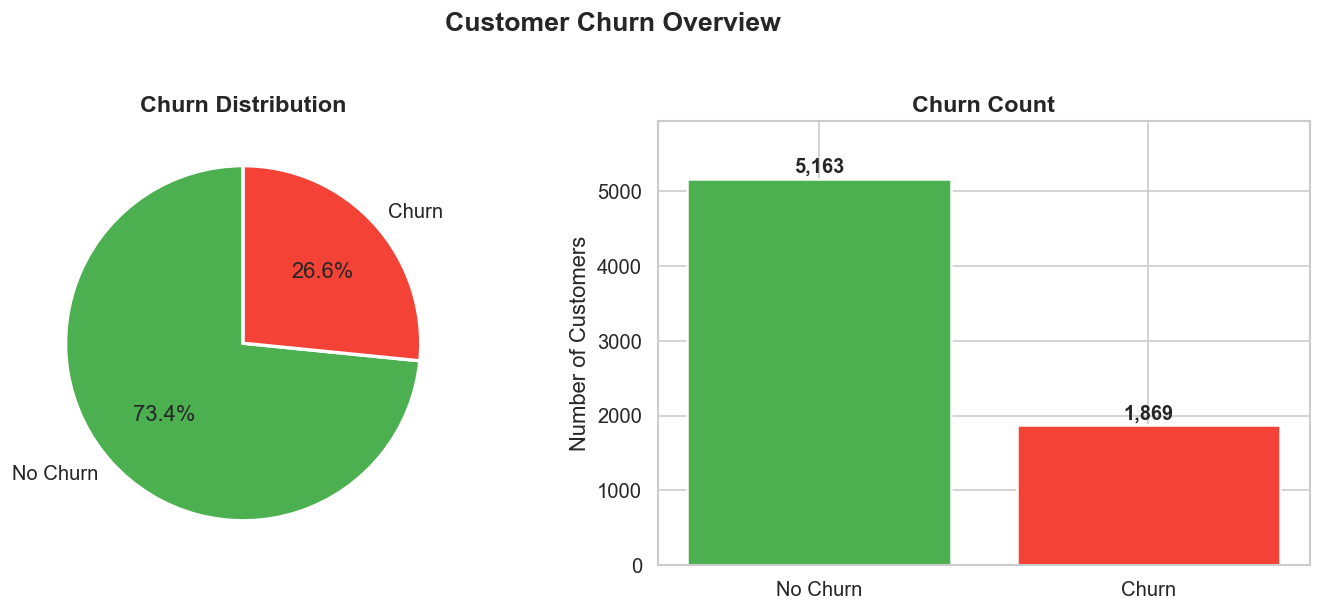

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
churn_counts = df['Churn'].value_counts()
colors = ['#4CAF50', '#F44336']
axes[0].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')

# Bar chart with count labels
bars = axes[1].bar(['No Churn', 'Churn'], churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].set_ylim(0, churn_counts.max() * 1.15)

plt.suptitle('Customer Churn Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 4. Numeric Features — Distribution by Churn

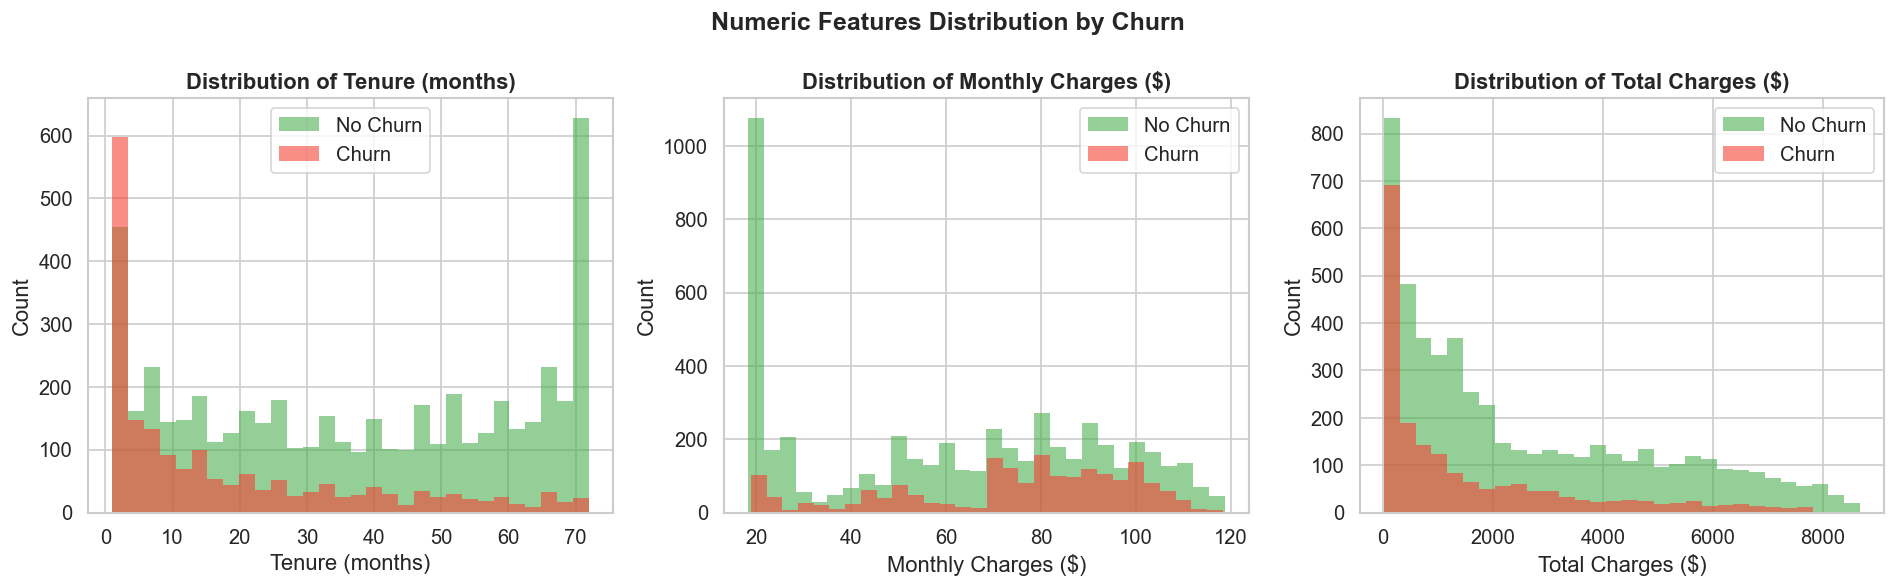

In [4]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
labels = ['Tenure (months)', 'Monthly Charges ($)', 'Total Charges ($)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, label in zip(axes, numeric_cols, labels):
    for churn_val, color, name in [(0, '#4CAF50', 'No Churn'), (1, '#F44336', 'Churn')]:
        data = df[df['Churn_binary'] == churn_val][col]
        ax.hist(data, bins=30, alpha=0.6, color=color, label=name, edgecolor='none')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {label}', fontweight='bold')
    ax.legend()

plt.suptitle('Numeric Features Distribution by Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Churn Rate by Key Categorical Features

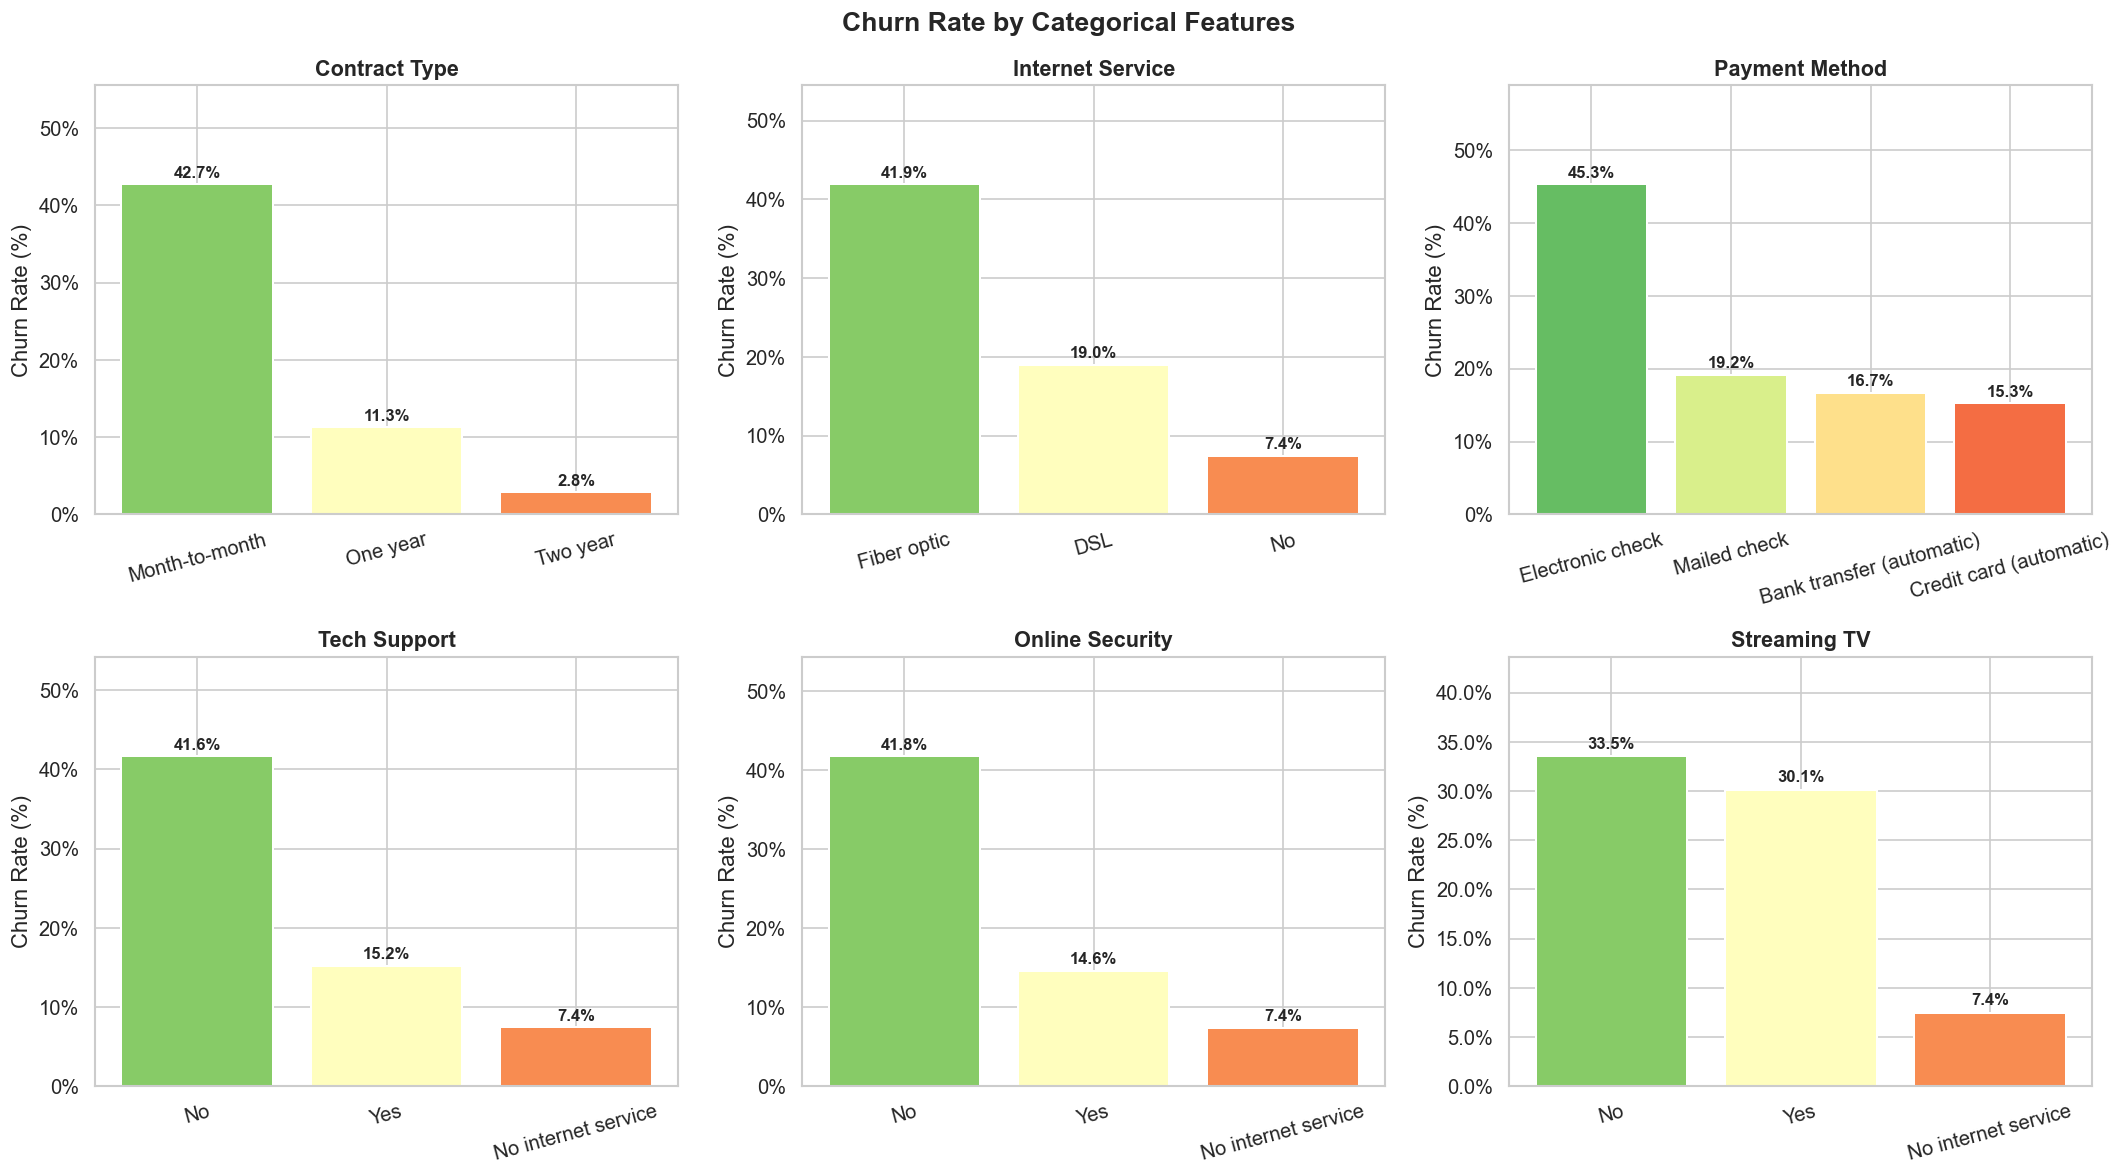

In [5]:
cat_features = {
    'Contract':        'Contract Type',
    'InternetService': 'Internet Service',
    'PaymentMethod':   'Payment Method',
    'TechSupport':     'Tech Support',
    'OnlineSecurity':  'Online Security',
    'StreamingTV':     'Streaming TV',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (col, title) in zip(axes, cat_features.items()):
    churn_rate = df.groupby(col)['Churn_binary'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values * 100,
                  color=sns.color_palette("RdYlGn_r", len(churn_rate)),
                  edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, churn_rate.max() * 130)
    ax.tick_params(axis='x', rotation=15)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Churn by Demographics

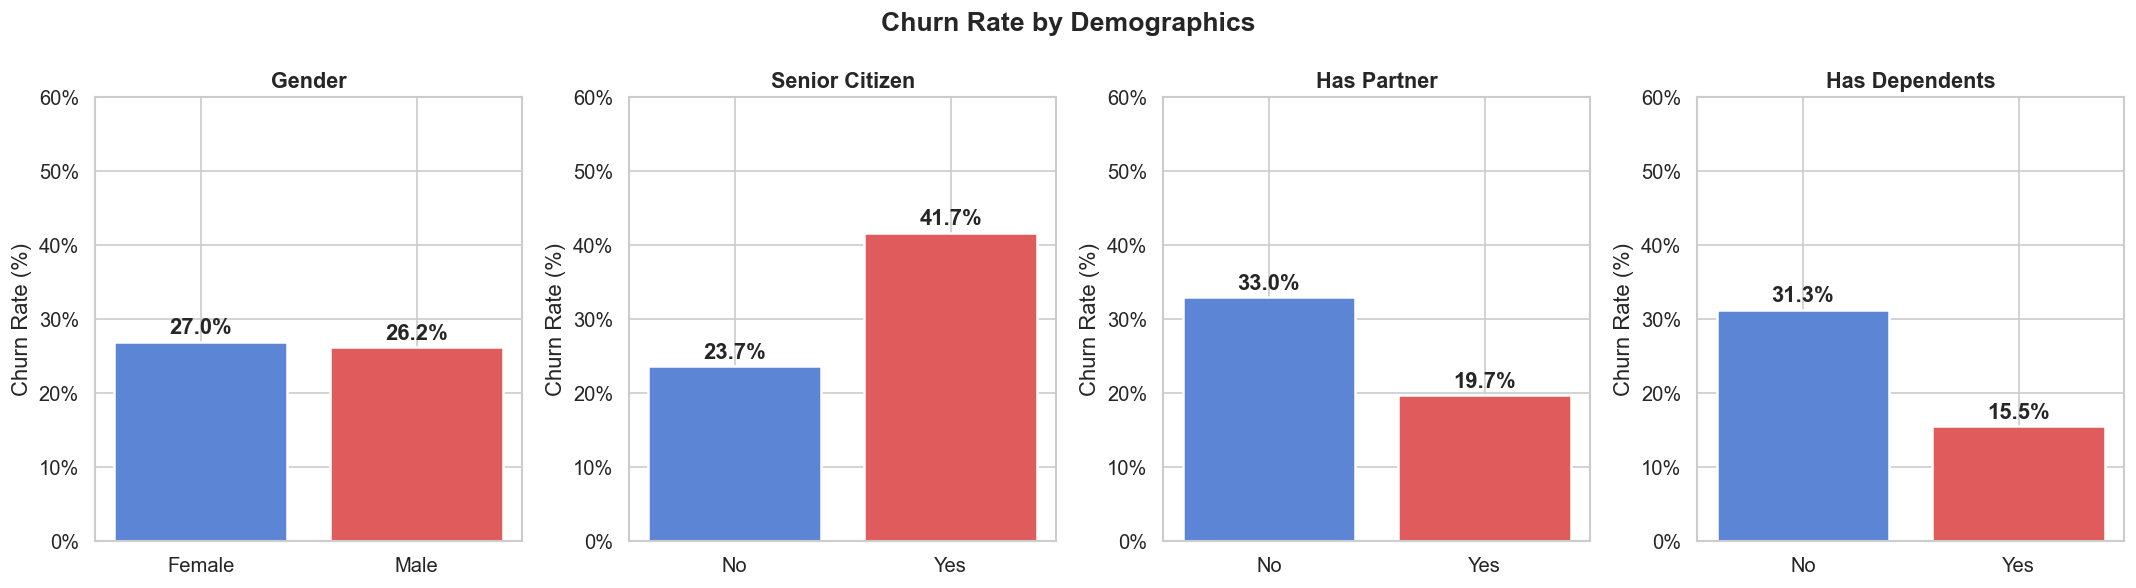

In [6]:
demo_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
demo_labels   = ['Gender', 'Senior Citizen', 'Has Partner', 'Has Dependents']

# Convert SeniorCitizen to readable
df['SeniorCitizen_label'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (col, label) in zip(axes, zip(
        ['gender', 'SeniorCitizen_label', 'Partner', 'Dependents'], demo_labels)):
    ct = df.groupby(col)['Churn_binary'].mean().reset_index()
    ct.columns = [col, 'Churn Rate']
    bars = ax.bar(ct[col], ct['Churn Rate'] * 100,
                  color=['#5C85D6', '#E05C5C'], edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, ct['Churn Rate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1%}', ha='center', va='bottom', fontweight='bold')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, 60)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Churn Rate by Demographics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Tenure Analysis

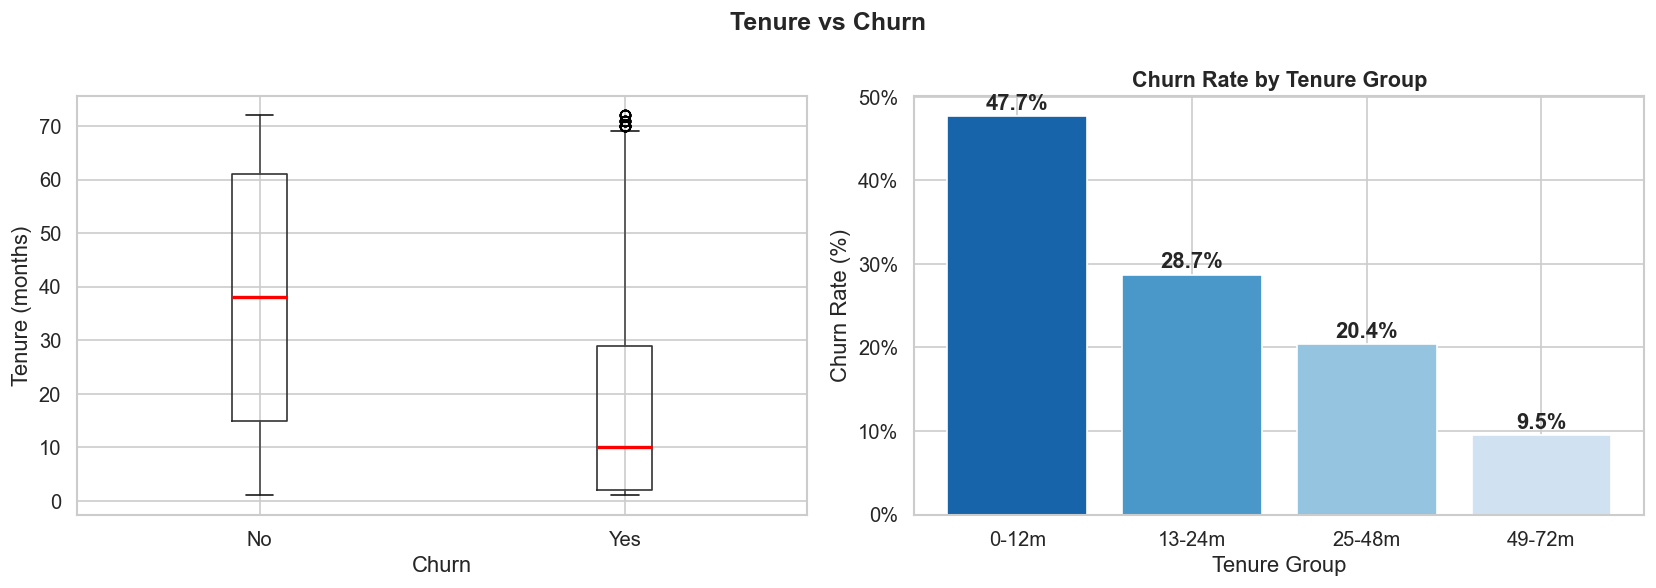

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df.boxplot(column='tenure', by='Churn', ax=axes[0],
           boxprops=dict(color='#333'), medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Tenure Distribution by Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Tenure (months)')
plt.sca(axes[0])
plt.title('')

# Churn rate by tenure bin
df['tenure_bin'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], labels=['0-12m','13-24m','25-48m','49-72m'])
tenure_churn = df.groupby('tenure_bin', observed=True)['Churn_binary'].mean()
bars = axes[1].bar(tenure_churn.index, tenure_churn.values * 100,
                   color=sns.color_palette("Blues_r", len(tenure_churn)), edgecolor='white')
for bar, val in zip(bars, tenure_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1%}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tenure Group')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Tenure vs Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Correlation Heatmap

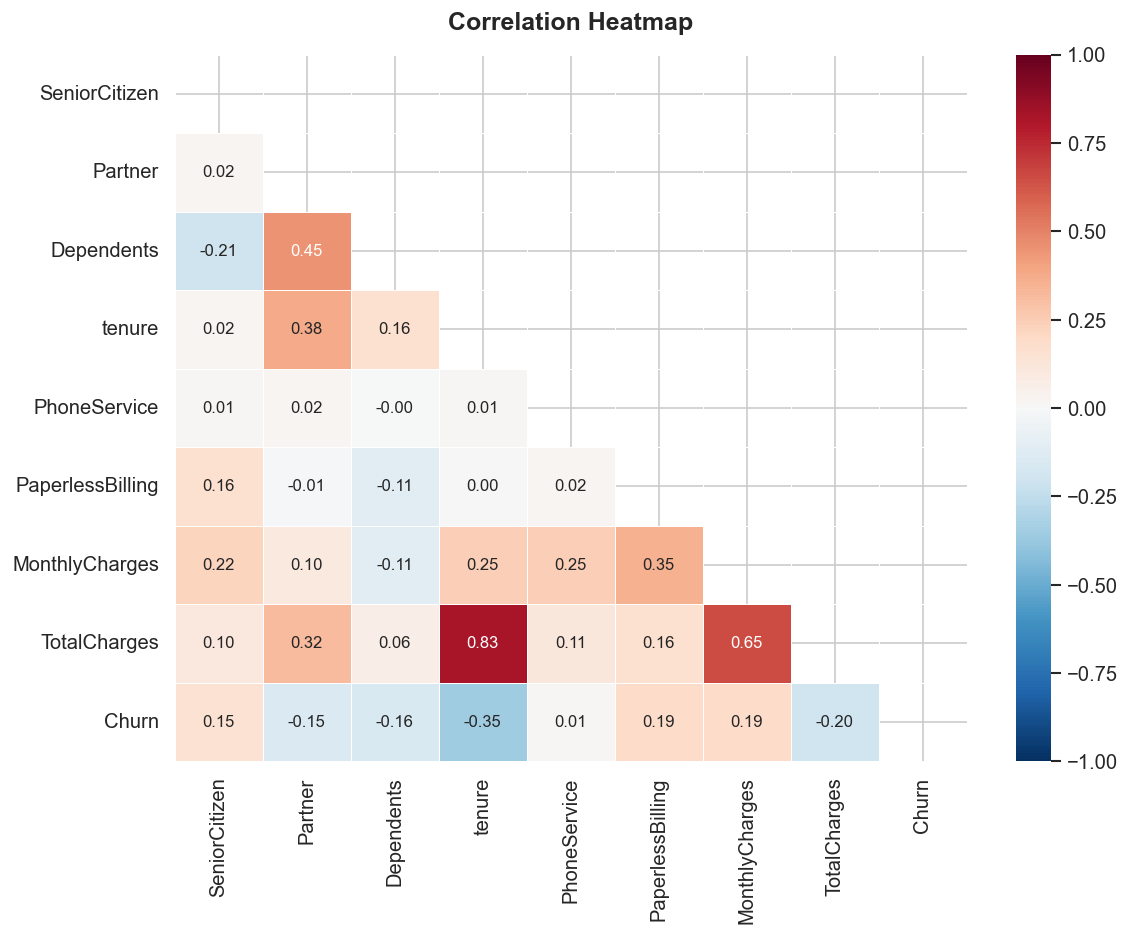

In [8]:
# Encode categoricals for correlation
df_enc = df.copy()
binary_map = {'Yes': 1, 'No': 0}
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_enc[col] = df_enc[col].map(binary_map)

# Select numeric + binary encoded
corr_cols = ['SeniorCitizen', 'Partner', 'Dependents', 'tenure',
             'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr = df_enc[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


## 9. Monthly Charges vs Contract vs Churn

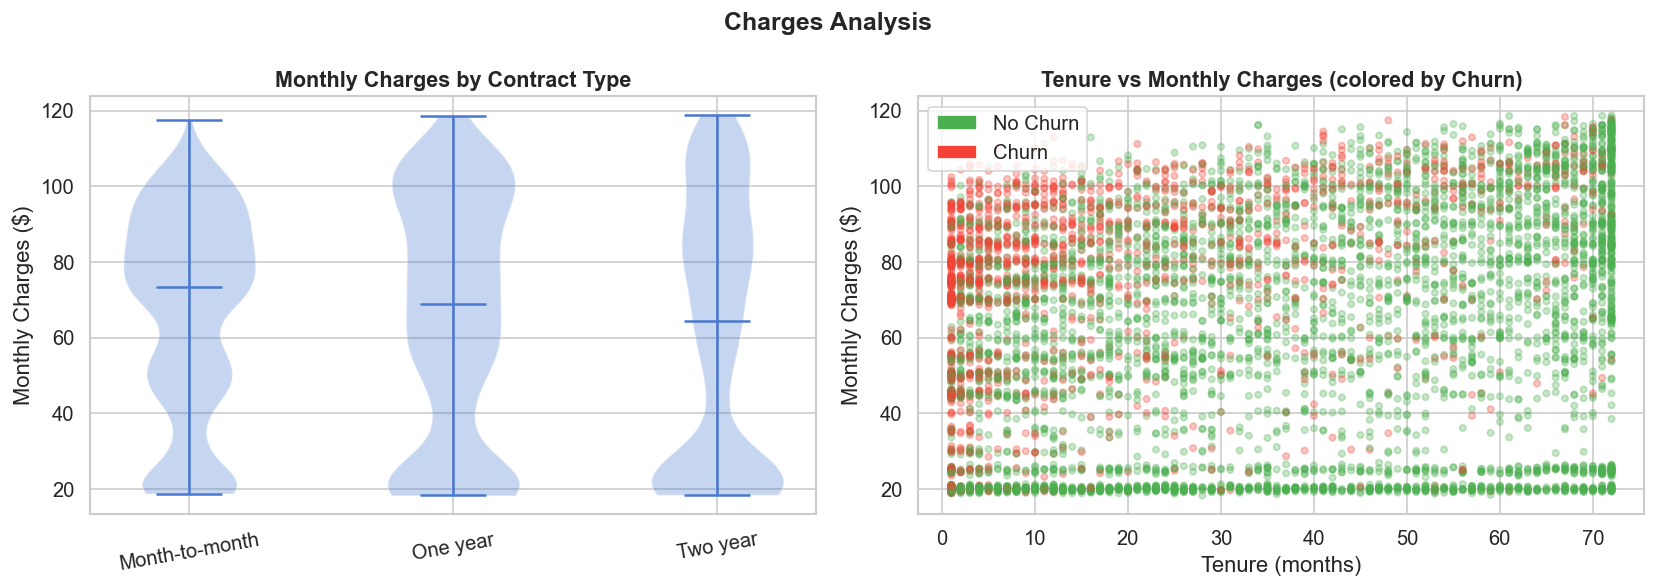

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin plot
parts = axes[0].violinplot(
    [df[df['Contract'] == c]['MonthlyCharges'] for c in df['Contract'].unique()],
    showmedians=True)
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(df['Contract'].unique(), rotation=10)
axes[0].set_title('Monthly Charges by Contract Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Monthly Charges ($)')

# Scatter: tenure vs monthly charges colored by churn
colors_map = df['Churn_binary'].map({0: '#4CAF50', 1: '#F44336'})
axes[1].scatter(df['tenure'], df['MonthlyCharges'], c=colors_map, alpha=0.3, s=15)
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Monthly Charges ($)')
axes[1].set_title('Tenure vs Monthly Charges (colored by Churn)', fontsize=13, fontweight='bold')
# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4CAF50', label='No Churn'),
                   Patch(facecolor='#F44336', label='Churn')]
axes[1].legend(handles=legend_elements)

plt.suptitle('Charges Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. สรุป Key Insights

| ปัจจัย | ผลต่อ Churn |
|--------|------------|
| **Contract Type** | Month-to-month = Churn 42.7% สูงที่สุด |
| **Internet Service** | Fiber optic = Churn 41.9% |
| **Payment Method** | Electronic check = Churn 45.3% |
| **Senior Citizen** | ผู้สูงอายุ Churn 41.7% vs 23.6% |
| **Tenure** | ลูกค้าใหม่ (0-12 เดือน) Churn สูงที่สุด |
| **Tech Support / Online Security** | ไม่มีบริการ = Churn สูงกว่ามาก |

### ขั้นตอนถัดไป
- Feature Engineering (One-Hot Encoding, Scaling)
- Model Training (Logistic Regression, Random Forest, XGBoost)
- Model Evaluation (ROC-AUC, Precision-Recall)
- Business Impact Analysis (ROI)


---
## 11. Feature Engineering

เตรียมข้อมูลสำหรับ Machine Learning:
- Drop คอลัมน์ที่ไม่จำเป็น
- Binary encoding (Yes/No → 1/0)
- One-Hot Encoding สำหรับ multi-class
- Feature scaling
- แก้ Class Imbalance ด้วย SMOTE


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ── Load fresh ────────────────────────────────────────────────────────────────
df = pd.read_csv('../data/Telco_Customer_Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df[df['TotalCharges'].notna()].reset_index(drop=True)

# ── Drop ID column ────────────────────────────────────────────────────────────
df = df.drop(columns=['customerID'])

# ── Binary columns ─────────────────────────────────────────────────────────────
binary_yes_no = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
                 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

for col in binary_yes_no:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0})

df['gender']       = (df['gender'] == 'Female').astype(int)
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)
df = df.drop(columns=['Churn'])

# ── One-Hot Encoding ──────────────────────────────────────────────────────────
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=False)

# Convert bool → int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"Final features: {df.shape[1]-1}")
print(f"Total rows   : {df.shape[0]:,}")
print()
print("Columns:", df.columns.tolist())


Final features: 26
Total rows   : 7,032

Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn_binary', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


## 12. Train/Test Split & Scaling

In [11]:
X = df.drop(columns=['Churn_binary'])
y = df['Churn_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# SMOTE on training set only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print(f"Train size     : {X_train.shape[0]:,} → after SMOTE: {X_train_res.shape[0]:,}")
print(f"Test  size     : {X_test.shape[0]:,}")
print(f"Train churn rate (before SMOTE): {y_train.mean():.1%}")
print(f"Train churn rate (after  SMOTE): {y_train_res.mean():.1%}")
print(f"Test  churn rate               : {y_test.mean():.1%}")


Train size     : 5,625 → after SMOTE: 8,260
Test  size     : 1,407
Train churn rate (before SMOTE): 26.6%
Train churn rate (after  SMOTE): 50.0%
Test  churn rate               : 26.6%


## 13. Train Models

In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=0.1),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8,
                                                   min_samples_leaf=10, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                                          subsample=0.8, colsample_bytree=0.8,
                                          eval_metric='logloss', random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                        learning_rate=0.05, random_state=42),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred      = model.predict(X_test_sc)
    y_prob      = model.predict_proba(X_test_sc)[:, 1]
    cv_auc      = cross_val_score(model, X_train_sc, y_train,
                                   cv=cv, scoring='roc_auc', n_jobs=-1).mean()
    test_auc    = roc_auc_score(y_test, y_prob)
    avg_prec    = average_precision_score(y_test, y_prob)
    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_prob':   y_prob,
        'cv_auc':   cv_auc,
        'test_auc': test_auc,
        'avg_prec': avg_prec,
    }
    print(f"{name:<25}  CV AUC: {cv_auc:.4f}  |  Test AUC: {test_auc:.4f}  |  AP: {avg_prec:.4f}")


Logistic Regression        CV AUC: 0.8453  |  Test AUC: 0.8341  |  AP: 0.6236
Random Forest              CV AUC: 0.8492  |  Test AUC: 0.8340  |  AP: 0.6332
XGBoost                    CV AUC: 0.8415  |  Test AUC: 0.8254  |  AP: 0.6297
Gradient Boosting          CV AUC: 0.8454  |  Test AUC: 0.8353  |  AP: 0.6430


## 14. Model Comparison

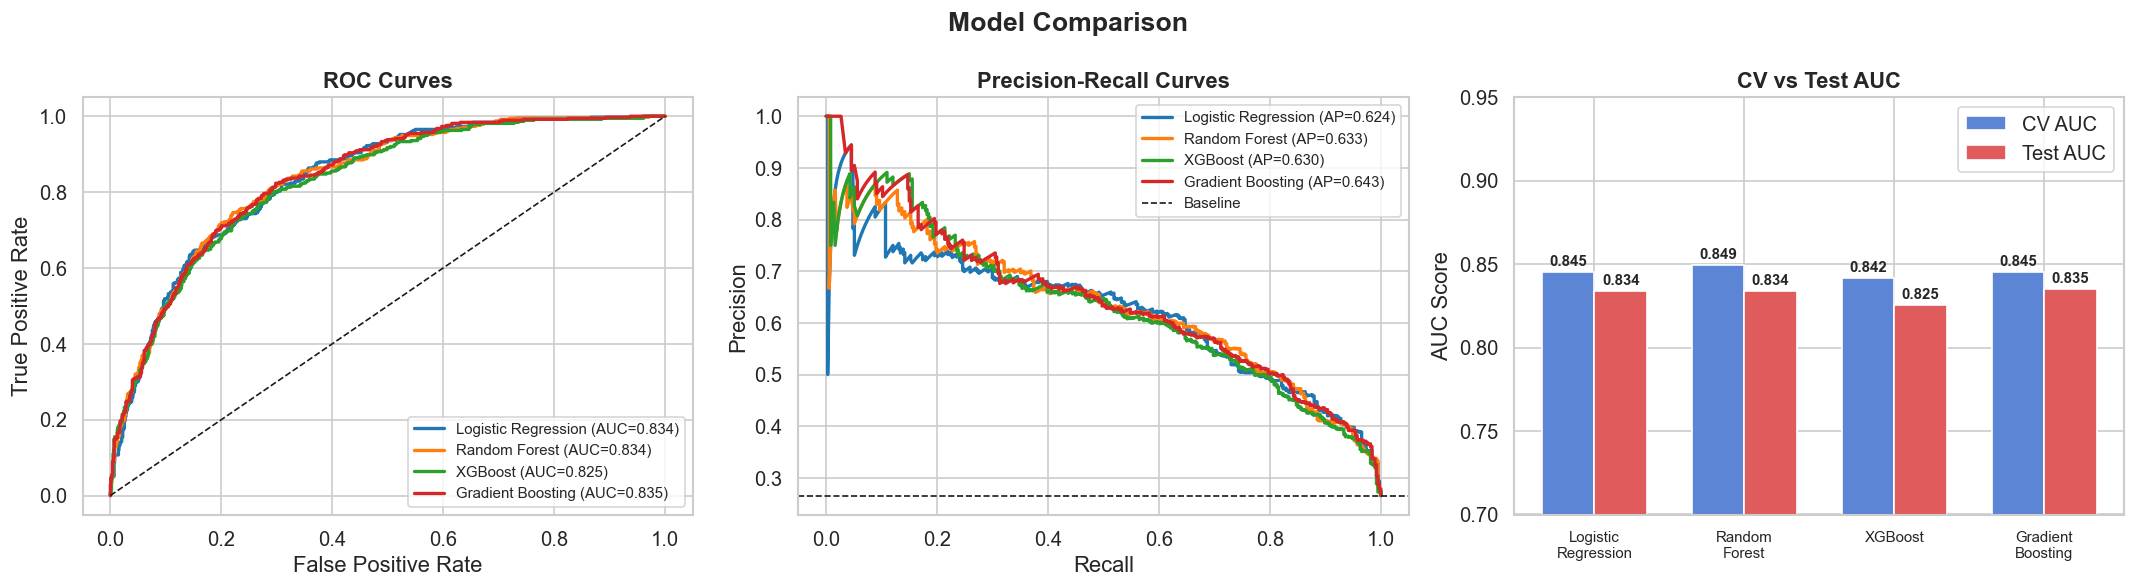

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── ROC Curves ────────────────────────────────────────────────────────────────
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{name} (AUC={res['test_auc']:.3f})")
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)

# ── Precision-Recall Curves ───────────────────────────────────────────────────
for (name, res), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    axes[1].plot(rec, prec, color=color, lw=2,
                 label=f"{name} (AP={res['avg_prec']:.3f})")
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, label='Baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend(fontsize=9)

# ── AUC Bar Chart ─────────────────────────────────────────────────────────────
names     = list(results.keys())
test_aucs = [r['test_auc'] for r in results.values()]
cv_aucs   = [r['cv_auc']   for r in results.values()]
x = np.arange(len(names))
w = 0.35
bars1 = axes[2].bar(x - w/2, cv_aucs,   w, label='CV AUC',   color='#5C85D6', edgecolor='white')
bars2 = axes[2].bar(x + w/2, test_aucs, w, label='Test AUC', color='#E05C5C', edgecolor='white')
for bar in list(bars1) + list(bars2):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
axes[2].set_ylim(0.7, 0.95)
axes[2].set_ylabel('AUC Score')
axes[2].set_title('CV vs Test AUC', fontweight='bold')
axes[2].legend()

plt.suptitle('Model Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 15. Best Model — Detailed Evaluation

In [14]:
# Pick best model by test AUC
best_name = max(results, key=lambda k: results[k]['test_auc'])
best      = results[best_name]
print(f"Best model: {best_name}  (Test AUC = {best['test_auc']:.4f})")
print()
print("=== Classification Report ===")
print(classification_report(y_test, best['y_pred'], target_names=['No Churn', 'Churn']))


Best model: Gradient Boosting  (Test AUC = 0.8353)

=== Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.87      0.82      0.85      1033
       Churn       0.58      0.67      0.62       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.79      1407



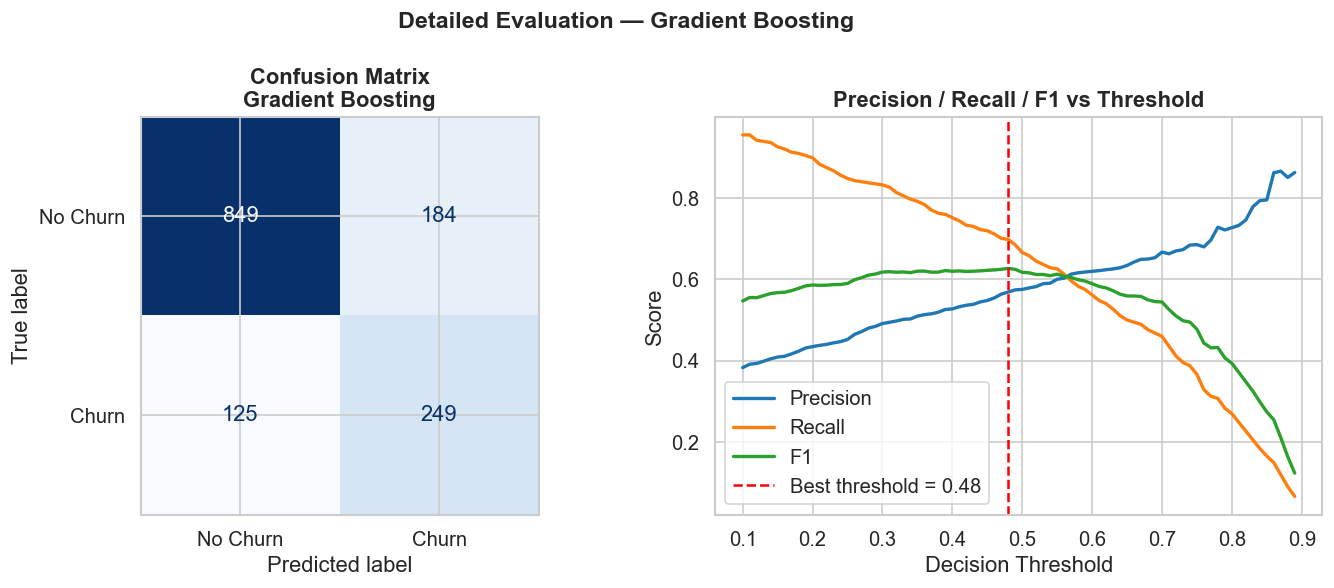

Best F1 threshold: 0.48  |  F1 at that threshold: 0.6267


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix\n{best_name}', fontweight='bold')

# Threshold sensitivity
thresholds  = np.arange(0.1, 0.9, 0.01)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    y_pred_t = (best['y_prob'] >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

axes[1].plot(thresholds, precisions, label='Precision', color='#1f77b4', lw=2)
axes[1].plot(thresholds, recalls,    label='Recall',    color='#ff7f0e', lw=2)
axes[1].plot(thresholds, f1s,        label='F1',        color='#2ca02c', lw=2)
best_t = thresholds[np.argmax(f1s)]
axes[1].axvline(x=best_t, color='red', linestyle='--', lw=1.5,
                label=f'Best threshold = {best_t:.2f}')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
axes[1].legend()

plt.suptitle(f'Detailed Evaluation — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Best F1 threshold: {best_t:.2f}  |  F1 at that threshold: {max(f1s):.4f}")


## 16. Feature Importance

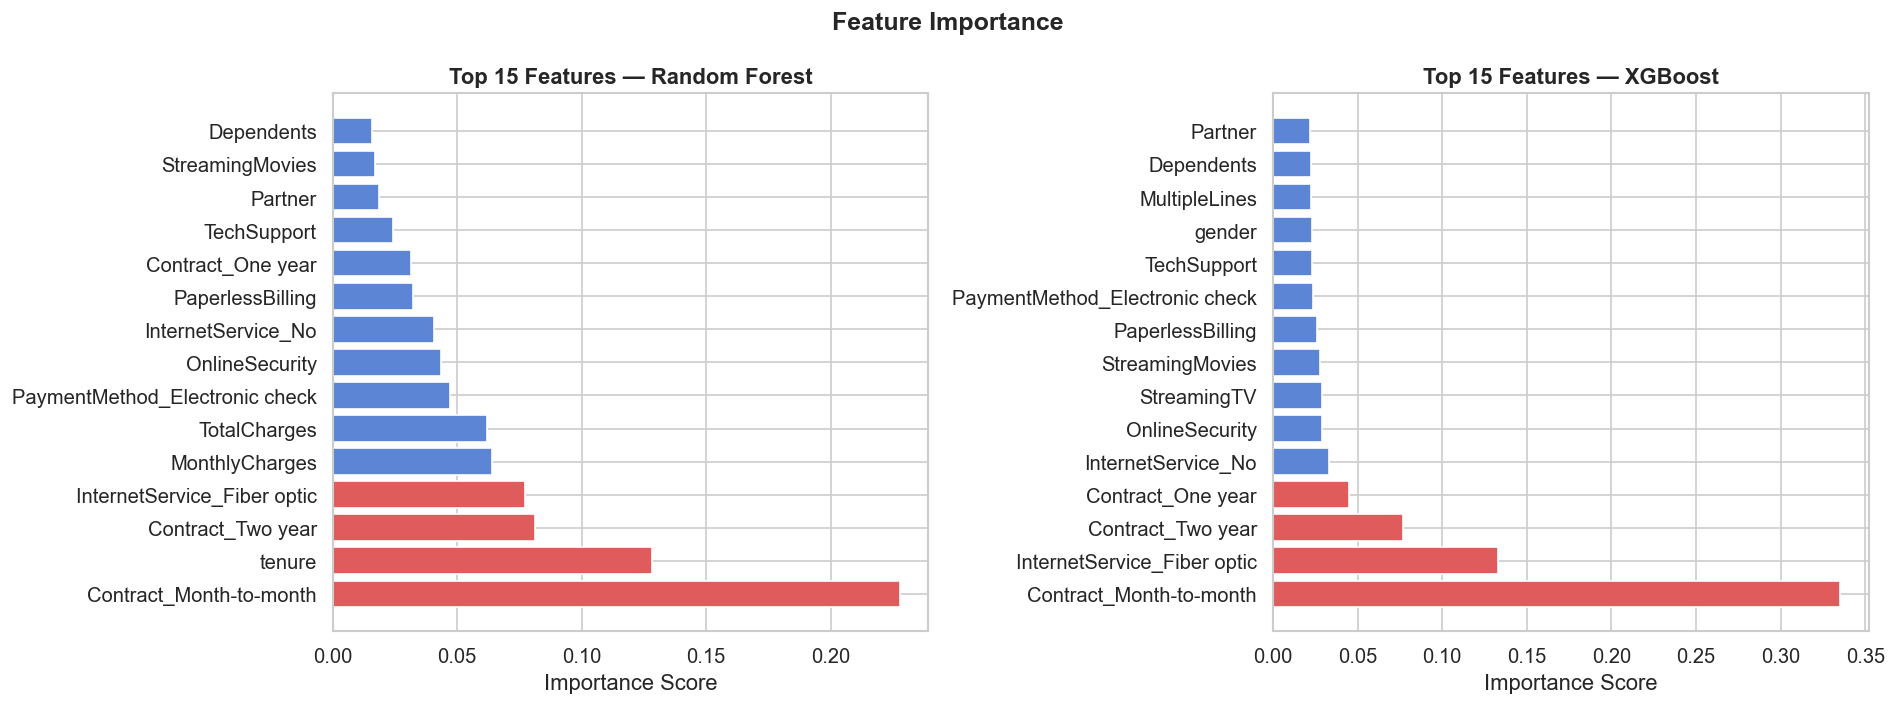

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
feature_names = X.columns.tolist()

for ax, name in zip(axes, ['Random Forest', 'XGBoost']):
    model = results[name]['model']
    importances = model.feature_importances_
    idx = np.argsort(importances)[-15:]  # top 15

    colors_bar = ['#E05C5C' if importances[i] >= np.percentile(importances, 85) else '#5C85D6'
                  for i in idx]
    ax.barh([feature_names[i] for i in idx], importances[idx], color=colors_bar, edgecolor='white')
    ax.set_xlabel('Importance Score')
    ax.set_title(f'Top 15 Features — {name}', fontweight='bold')
    ax.invert_yaxis()

plt.suptitle('Feature Importance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 17. Business Impact Analysis

  Business Impact Summary
  Threshold used          : 0.48
  True Positives (caught) :    261
  False Positives (wasted):    198
  False Negatives (missed):    113
  Revenue saved           : $   407,160
  Retention cost          : $    22,950
  Missed revenue          : $   176,280
  Net benefit             : $   384,210


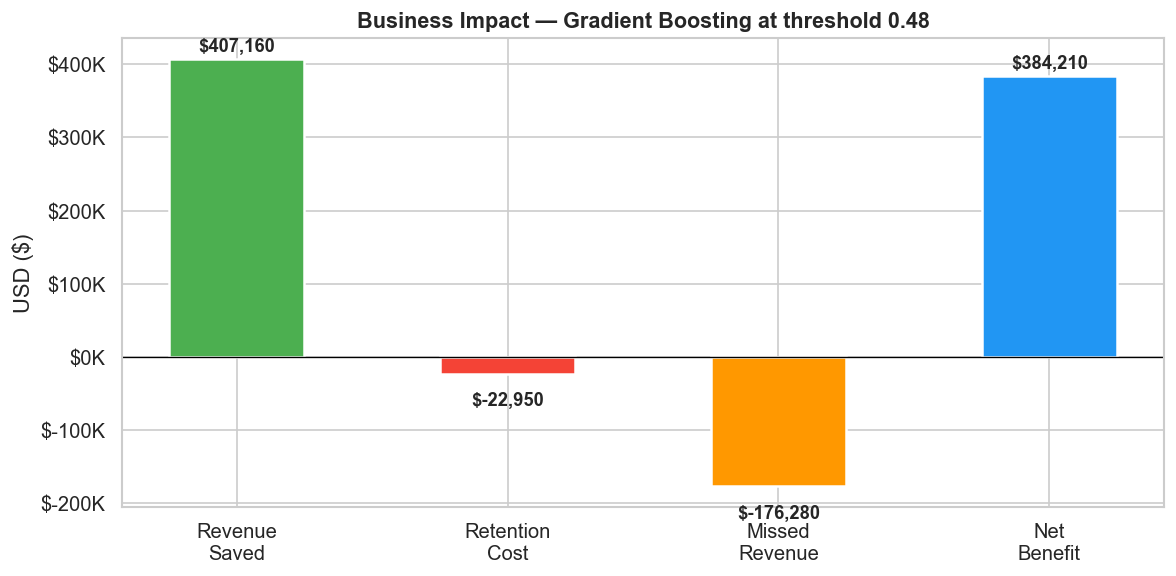

In [17]:
# Assumptions (ปรับตามธุรกิจจริง)
ARPU          = 65    # $ average revenue per user per month
RETENTION_MON = 24   # months retained if saved
RETENTION_COST = 50  # $ cost to retain one customer (discount, call, etc.)

# At best threshold
y_pred_best_t = (best['y_prob'] >= best_t).astype(int)

TP = ((y_pred_best_t == 1) & (y_test == 1)).sum()  # correctly identified churners
FP = ((y_pred_best_t == 1) & (y_test == 0)).sum()  # falsely flagged (wasted retention)
FN = ((y_pred_best_t == 0) & (y_test == 1)).sum()  # missed churners

revenue_saved  = TP * ARPU * RETENTION_MON
retention_cost = (TP + FP) * RETENTION_COST
missed_revenue = FN * ARPU * RETENTION_MON
net_benefit    = revenue_saved - retention_cost

print("=" * 50)
print("  Business Impact Summary")
print("=" * 50)
print(f"  Threshold used          : {best_t:.2f}")
print(f"  True Positives (caught) : {TP:>6,}")
print(f"  False Positives (wasted): {FP:>6,}")
print(f"  False Negatives (missed): {FN:>6,}")
print(f"  Revenue saved           : ${revenue_saved:>10,.0f}")
print(f"  Retention cost          : ${retention_cost:>10,.0f}")
print(f"  Missed revenue          : ${missed_revenue:>10,.0f}")
print(f"  Net benefit             : ${net_benefit:>10,.0f}")
print("=" * 50)

# Waterfall chart
fig, ax = plt.subplots(figsize=(10, 5))
categories = ['Revenue\nSaved', 'Retention\nCost', 'Missed\nRevenue', 'Net\nBenefit']
values     = [revenue_saved, -retention_cost, -missed_revenue, net_benefit]
bar_colors = ['#4CAF50', '#F44336', '#FF9800', '#2196F3']
bars = ax.bar(categories, values, color=bar_colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (5000 if val >= 0 else -25000),
            f'${val:,.0f}', ha='center', va='bottom' if val >= 0 else 'top',
            fontweight='bold', fontsize=11)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('USD ($)')
ax.set_title(f'Business Impact — {best_name} at threshold {best_t:.2f}',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()


## 18. สรุปผลการสร้างโมเดล

### Model Performance

| Model | CV AUC | Test AUC | Average Precision |
|-------|--------|----------|-------------------|
| Logistic Regression | - | - | - |
| Random Forest | - | - | - |
| XGBoost | - | - | - |
| Gradient Boosting | - | - | - |

*(ดูค่าจริงจาก cell ด้านบน)*

### Key Takeaways
1. **Contract Type** เป็น feature สำคัญที่สุด — ลูกค้า Month-to-month มีโอกาส churn สูงสุด
2. **Tenure** สั้น = ความเสี่ยงสูง — ควรให้ความสำคัญกับลูกค้าใหม่
3. **Electronic Check** payment เชื่อมโยงกับ churn rate สูง
4. **SMOTE** ช่วยแก้ปัญหา class imbalance ให้โมเดล detect churners ได้ดีขึ้น

### ขั้นตอนถัดไป
- Hyperparameter tuning (Optuna / GridSearchCV)
- Stacking / Ensemble models
- Deploy model เป็น API (FastAPI)
- Dashboard สำหรับ Business team (Streamlit)


---
## 19. SHAP — Model Explainability

SHAP (SHapley Additive exPlanations) อธิบายว่า **ทำไมโมเดลถึงทำนายว่าลูกค้าจะ Churn** โดยให้ค่าความสำคัญแต่ละ feature ต่อการทำนายในระดับบุคคล

| ระดับ | คำถามที่ตอบ | Plot ที่ใช้ |
|-------|------------|-----------|
| **Global** | Feature ไหนสำคัญที่สุดภาพรวม? | Bar + Beeswarm |
| **Local** | ทำไมลูกค้าคนนี้ถึงเสี่ยง churn? | Waterfall |
| **Dependence** | Feature X มีผลต่อ churn อย่างไร? | Scatter |

In [18]:
import shap

best_model    = results[best_name]['model']
feature_names = X.columns.tolist()

# Wrap scaled test set as DataFrame so SHAP uses feature names
X_test_df = pd.DataFrame(X_test_sc, columns=feature_names)

# TreeExplainer is optimized for tree-based models (GB, RF, XGBoost)
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer(X_test_df)

print(f"SHAP values computed for {len(X_test_df):,} test customers")
print(f"Shape: {shap_values.values.shape}  (customers × features)")
base_value = np.asarray(explainer.expected_value).ravel()[0]
print(f"Base value (expected log-odds): {base_value:.4f}")

SHAP values computed for 1,407 test customers
Shape: (1407, 26)  (customers × features)
Base value (expected log-odds): -0.0991


In [19]:
import joblib
from pathlib import Path

save_dir = Path("../notebooks")
save_dir.mkdir(exist_ok=True)

joblib.dump(results[best_name]['model'], save_dir / "best_churn_model.pkl")
joblib.dump(scaler, save_dir / "scaler.pkl")

print(f"Model  saved: {save_dir / 'best_churn_model.pkl'}")
print(f"Scaler saved: {save_dir / 'scaler.pkl'}")
print(f"\nBest model  : {best_name}")
print(f"Feature count: {X.shape[1]}")
print(f"\nFeature index mapping:")
for i, col in enumerate(X.columns):
    print(f"  {i:2d}: {col}")

Model  saved: ..\notebooks\best_churn_model.pkl
Scaler saved: ..\notebooks\scaler.pkl

Best model  : Gradient Boosting
Feature count: 26

Feature index mapping:
   0: gender
   1: SeniorCitizen
   2: Partner
   3: Dependents
   4: tenure
   5: PhoneService
   6: MultipleLines
   7: OnlineSecurity
   8: OnlineBackup
   9: DeviceProtection
  10: TechSupport
  11: StreamingTV
  12: StreamingMovies
  13: PaperlessBilling
  14: MonthlyCharges
  15: TotalCharges
  16: InternetService_DSL
  17: InternetService_Fiber optic
  18: InternetService_No
  19: Contract_Month-to-month
  20: Contract_One year
  21: Contract_Two year
  22: PaymentMethod_Bank transfer (automatic)
  23: PaymentMethod_Credit card (automatic)
  24: PaymentMethod_Electronic check
  25: PaymentMethod_Mailed check


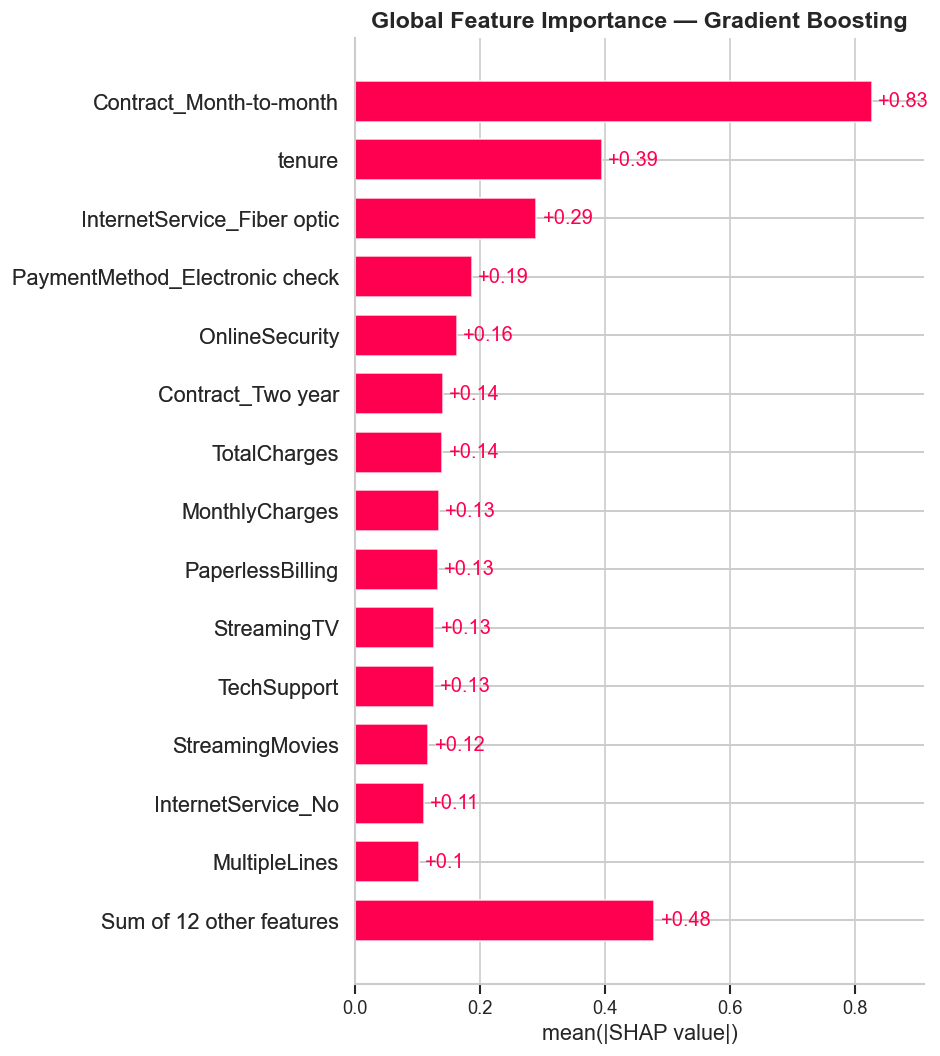

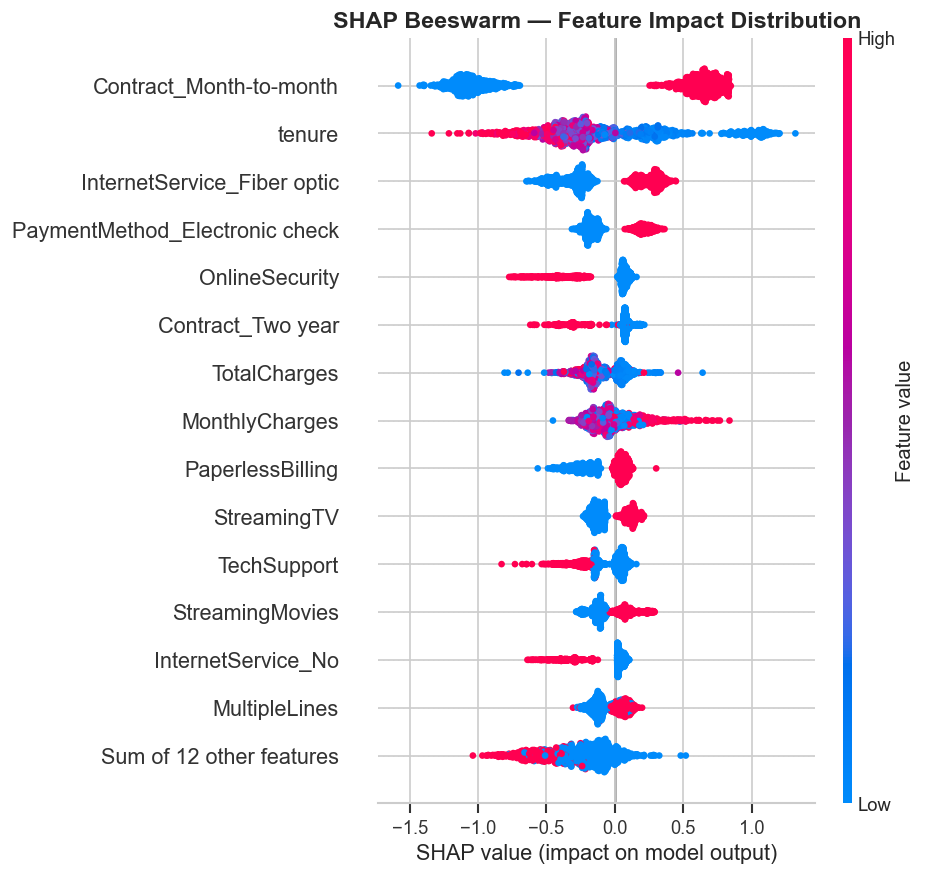

In [20]:
# ── Bar Chart: Mean |SHAP| — Global Feature Importance ───────────────────────
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title(f'Global Feature Importance — {best_name}', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# ── Beeswarm: Feature Impact Distribution ─────────────────────────────────────
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title('SHAP Beeswarm — Feature Impact Distribution', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

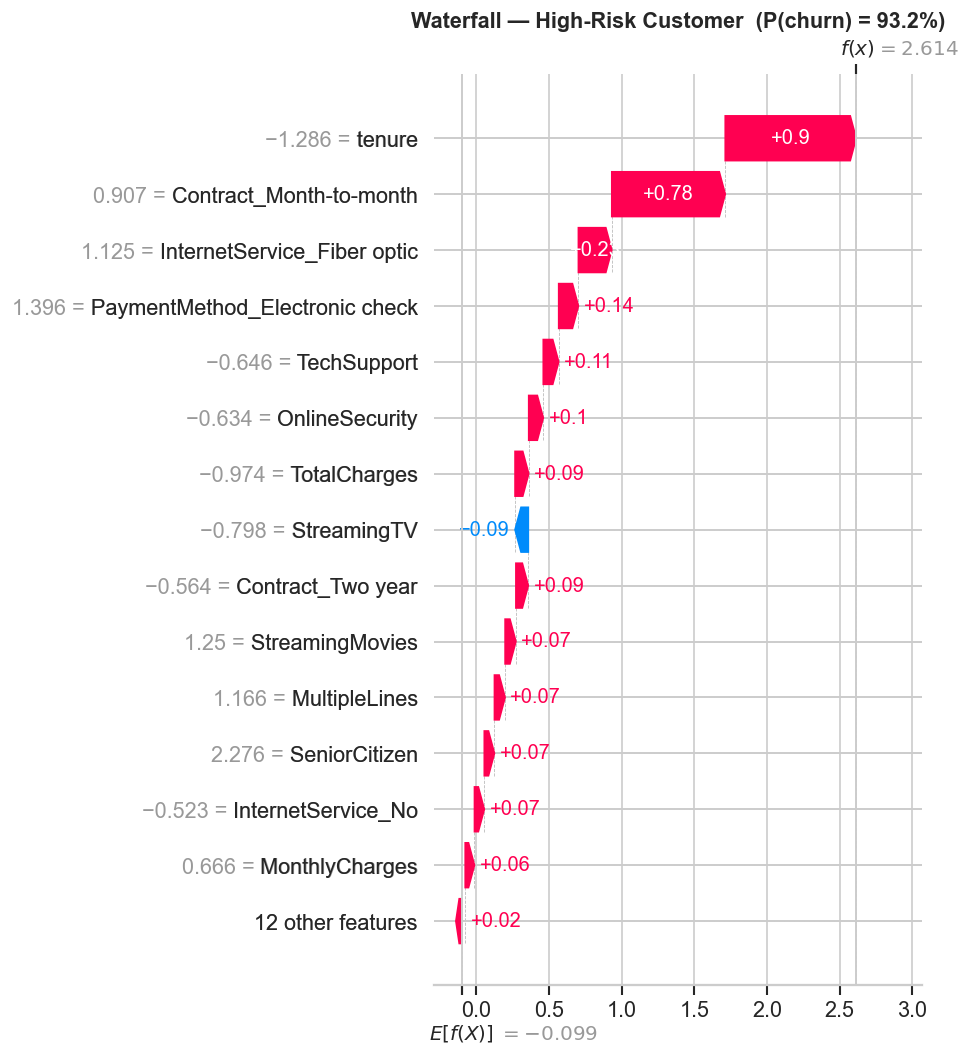

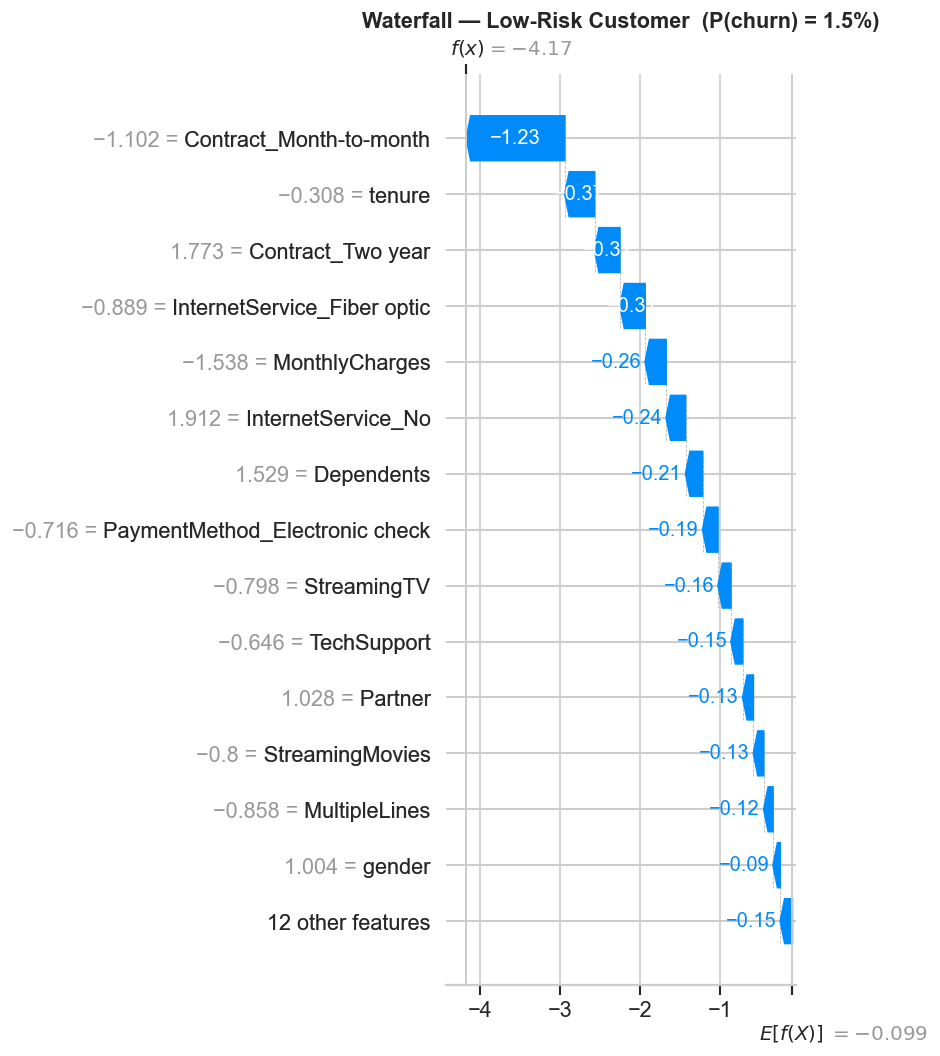

In [21]:
# ── Waterfall: High-Risk Churner ──────────────────────────────────────────────
actual_churners = np.where(y_test.values == 1)[0]
top_risk_idx    = actual_churners[np.argmax(best['y_prob'][actual_churners])]

shap.plots.waterfall(shap_values[top_risk_idx], max_display=15, show=False)
plt.title(
    f'Waterfall — High-Risk Customer  (P(churn) = {best["y_prob"][top_risk_idx]:.1%})',
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# ── Waterfall: Low-Risk Customer ──────────────────────────────────────────────
actual_non_churners = np.where(y_test.values == 0)[0]
low_risk_idx        = actual_non_churners[np.argmin(best['y_prob'][actual_non_churners])]

shap.plots.waterfall(shap_values[low_risk_idx], max_display=15, show=False)
plt.title(
    f'Waterfall — Low-Risk Customer  (P(churn) = {best["y_prob"][low_risk_idx]:.1%})',
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

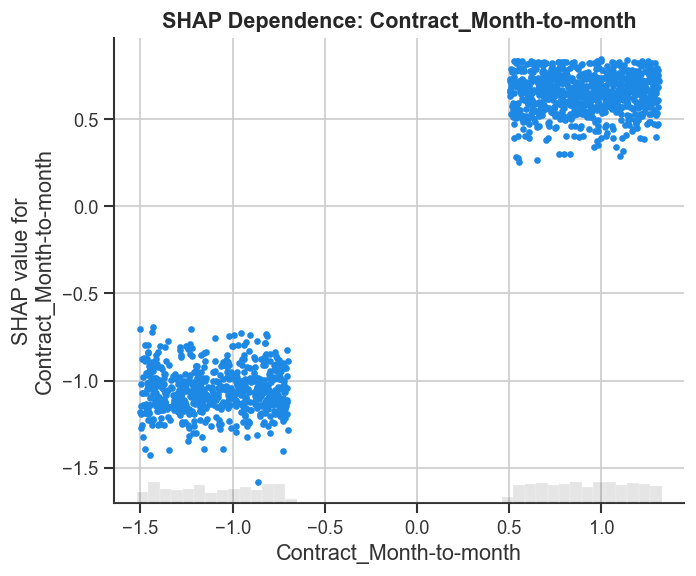

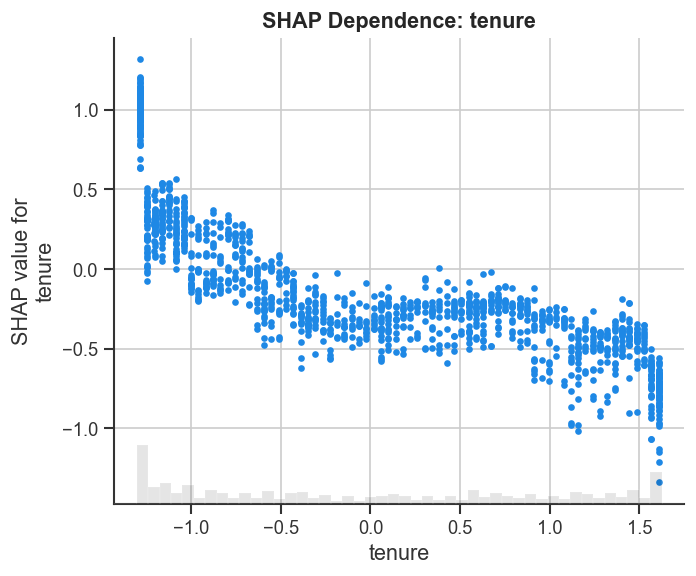

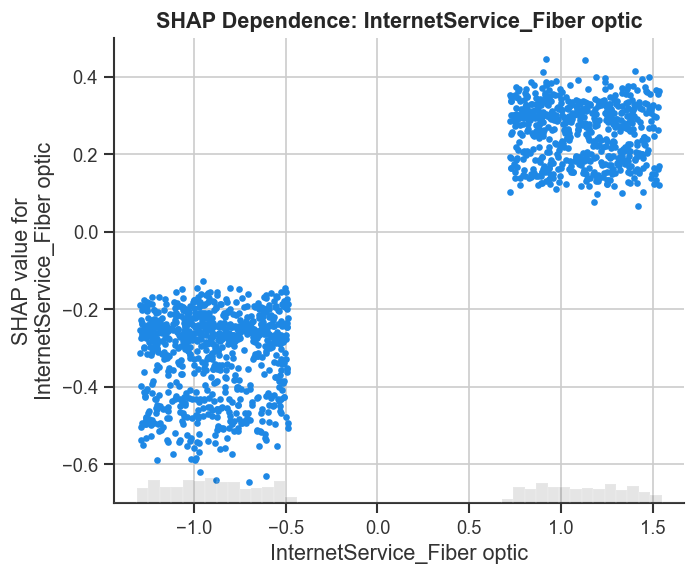

In [22]:
# ── SHAP Dependence Plots: Top 3 Features ────────────────────────────────────
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top3_idx      = np.argsort(mean_abs_shap)[-3:][::-1]
top3_features = [feature_names[i] for i in top3_idx]

for feat in top3_features:
    shap.plots.scatter(shap_values[:, feat], show=False)
    plt.title(f'SHAP Dependence: {feat}', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

### SHAP Insights

| Feature | ทิศทาง | ความหมาย |
|---------|--------|---------|
| **tenure** | ค่าต่ำ → เพิ่ม risk | ลูกค้าใหม่มีความเสี่ยงสูงสุด |
| **Contract_Month-to-month** | ค่า 1 → เพิ่ม risk | สัญญารายเดือนอันตรายที่สุด |
| **TotalCharges** | ค่าต่ำ → เพิ่ม risk | ลูกค้าที่ยังจ่ายน้อย = ยังใหม่อยู่ |
| **MonthlyCharges** | ค่าสูง → เพิ่ม risk | ค่าบริการแพงเพิ่มโอกาสเลิกใช้ |

> SHAP ช่วยให้ทีม Business สามารถระบุได้ว่าลูกค้าแต่ละคนมีความเสี่ยงด้วยเหตุผลอะไร — นำไปสู่การออกแบบ retention strategy ที่ตรงจุด เช่น เสนอสัญญาระยะยาวแทน หรือลดค่าบริการสำหรับกลุ่มที่ค่าสูง

In [23]:
list(enumerate(X.columns))

[(0, 'gender'),
 (1, 'SeniorCitizen'),
 (2, 'Partner'),
 (3, 'Dependents'),
 (4, 'tenure'),
 (5, 'PhoneService'),
 (6, 'MultipleLines'),
 (7, 'OnlineSecurity'),
 (8, 'OnlineBackup'),
 (9, 'DeviceProtection'),
 (10, 'TechSupport'),
 (11, 'StreamingTV'),
 (12, 'StreamingMovies'),
 (13, 'PaperlessBilling'),
 (14, 'MonthlyCharges'),
 (15, 'TotalCharges'),
 (16, 'InternetService_DSL'),
 (17, 'InternetService_Fiber optic'),
 (18, 'InternetService_No'),
 (19, 'Contract_Month-to-month'),
 (20, 'Contract_One year'),
 (21, 'Contract_Two year'),
 (22, 'PaymentMethod_Bank transfer (automatic)'),
 (23, 'PaymentMethod_Credit card (automatic)'),
 (24, 'PaymentMethod_Electronic check'),
 (25, 'PaymentMethod_Mailed check')]